# Лабораторная работа №2: Решение систем нелинейных уравнений
## Студент: Сергиенко Александр Сергеевич
### Группы: ФИТ-231
## Система уравнений:  
###    x^2+y^2−4=0
###    3x^2−y=0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Заданная точность
eps = 0.001

# Определение системы уравнений F(X) = 0
def f1(x, y):
    return x**2 + y**2 - 4

def f2(x, y):
    return 3*x**2 - y

# Вектор-функция системы
def F(X):
    x, y = X
    return np.array([f1(x, y), f2(x, y)])

# Матрица Якоби системы
def Jacobian(X):
    x, y = X
    return np.array([
        [2*x, 2*y],
        [6*x, -1.0]
    ])

## 1. Решение задачи отделения корней графическим способом

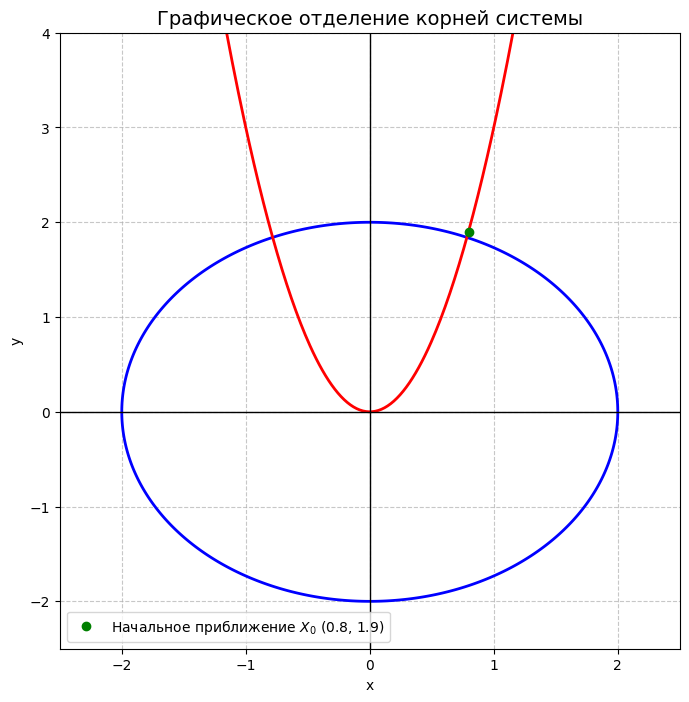

In [11]:
# Графическое отделение корней
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = np.linspace(-2.5, 4, 400)
X, Y = np.meshgrid(x_vals, y_vals)

plt.figure(figsize=(8, 8))

# График окружности (F1 = 0)
plt.contour(X, Y, f1(X, Y), levels=[0], colors='blue', linewidths=2)
# График параболы (F2 = 0)
plt.plot(x_vals, 3*x_vals**2, color='red', linewidth=2)

# Marking the approximate root
plt.plot(0.8, 1.9, 'go', label='Начальное приближение $X_0$ (0.8, 1.9)')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 4)
plt.title("Графическое отделение корней системы", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 2. Уточнение корня методами вычислительной математики

In [15]:
def simple_iteration_method(X0, eps, max_iter=100):
    """
    Метод простой итерации для специально преобразованной системы.
    X0 - начальное приближение [x, y]
    """
    X_prev = np.array(X0, dtype=float)
    print("--- Метод простой итерации ---")
    
    for i in range(max_iter):
        x_prev, y_prev = X_prev
        
        # Вычисление следующего приближения по сходящейся схеме
        x_next = np.sqrt(y_prev / 3.0)
        y_next = np.sqrt(4.0 - y_prev / 3.0)
        
        X_next = np.array([x_next, y_next])
        
        # Вычисление нормы разности для критерия останова
        norm_diff = np.linalg.norm(X_next - X_prev)
        
        # Вывод текущей итерации
        print(f"Итерация {i+1}: x = {X_next[0]:.6f}, y = {X_next[1]:.6f}, ||dx|| = {norm_diff:.6f}")
        
        if norm_diff < eps:
            print(f"\nСходимость достигнута за {i+1} итераций.\n")
            return X_next, i+1
            
        X_prev = X_next
        
    print("Предупреждение: Превышено максимальное число итераций!")
    return X_prev, max_iter

# Запуск метода простой итерации
X0 = [0.8, 1.9]
x_si, iters_si = simple_iteration_method(X0, eps)

--- Метод простой итерации ---
Итерация 1: x = 0.795822, y = 1.834848, ||dx|| = 0.065286
Итерация 2: x = 0.782059, y = 1.840756, ||dx|| = 0.014978
Итерация 3: x = 0.783317, y = 1.840221, ||dx|| = 0.001367
Итерация 4: x = 0.783203, y = 1.840270, ||dx|| = 0.000124

Сходимость достигнута за 4 итераций.



## 2.2 Метод Ньютона (касательных)

In [13]:
def newton_method_system(X0, eps, max_iter=100):
    """
    Метод Ньютона для решения системы нелинейных уравнений.
    X0 - начальное приближение [x, y]
    """
    X_prev = np.array(X0, dtype=float)
    print("--- Метод Ньютона ---")
    
    for i in range(max_iter):
        # Решение СЛАУ J * delta = -F
        try:
            delta = np.linalg.solve(Jacobian(X_prev), -F(X_prev))
        except np.linalg.LinAlgError:
            print("Ошибка: Вырожденная матрица Якоби!")
            return X_prev, max_iter
            
        X_next = X_prev + delta
        norm_diff = np.linalg.norm(delta)
        
        # Вывод текущей итерации
        print(f"Итерация {i+1}: x = {X_next[0]:.6f}, y = {X_next[1]:.6f}, ||dx|| = {norm_diff:.6f}")
        
        if norm_diff < eps:
            print(f"\nСходимость достигнута за {i+1} итераций.\n")
            return X_next, i+1
            
        X_prev = X_next
        
    print("Предупреждение: Превышено максимальное число итераций!")
    return X_prev, max_iter

# Запуск метода Ньютона
x_nt, iters_nt = newton_method_system(X0, eps)

--- Метод Ньютона ---
Итерация 1: x = 0.783569, y = 1.841129, ||dx|| = 0.061121
Итерация 2: x = 0.783213, y = 1.840266, ||dx|| = 0.000934

Сходимость достигнута за 2 итераций.



## 3. Проверка корректности нахождения корня

In [14]:
print("--- Проверка корректности (Метод простой итерации) ---")
residuals_si = F(x_si)
print(f"Найденный корень: x = {x_si[0]:.6f}, y = {x_si[1]:.6f}")
print(f"F1(x,y) = x^2 + y^2 - 4 = {residuals_si[0]:.2e}")
print(f"F2(x,y) = 3x^2 - y     = {residuals_si[1]:.2e}")
print(f"Норма невязки ||F(X)|| = {np.linalg.norm(residuals_si):.2e}\n")

print("--- Проверка корректности (Метод Ньютона) ---")
residuals_nt = F(x_nt)
print(f"Найденный корень: x = {x_nt[0]:.6f}, y = {x_nt[1]:.6f}")
print(f"F1(x,y) = x^2 + y^2 - 4 = {residuals_nt[0]:.2e}")
print(f"F2(x,y) = 3x^2 - y     = {residuals_nt[1]:.2e}")
print(f"Норма невязки ||F(X)|| = {np.linalg.norm(residuals_nt):.2e}")

--- Проверка корректности (Метод простой итерации) ---
Найденный корень: x = -inf, y = -inf
F1(x,y) = x^2 + y^2 - 4 = inf
F2(x,y) = 3x^2 - y     = inf
Норма невязки ||F(X)|| = inf

--- Проверка корректности (Метод Ньютона) ---
Найденный корень: x = 0.783213, y = 1.840266
F1(x,y) = x^2 + y^2 - 4 = 8.72e-07
F2(x,y) = 3x^2 - y     = 3.80e-07
Норма невязки ||F(X)|| = 9.51e-07
